In [10]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx

In [11]:
# 1)  IMPORT 
# import graph de l'aéroport
chemin_xml = "../data/airportsAndCoordAndPop.graphml"
graph  = nx.read_graphml(chemin_xml)
# conversion du graph et attribution des caractéristiques aux noeuds
data_0=from_networkx(graph, group_node_attrs=["lon", "lat", "population"])


In [12]:
pays = data_0['country']
ville = data_0['city_name']
# décompte des occurrences de chaque pays
#from collections import Counter
#freq = Counter(pays)
#print(freq)  # Output: Counter({'c': 3, 'a': 2, 'b': 1})   

import pandas as pd
lespays=pd.Series(pays).value_counts()

# nombre de connexions  par aéroport
edge=data_0.edge_index 
nb_connection = edge.size(1)
print(nb_connection)
# nombre de connexions par aéroport

nb_connection_sortantes = pd.Series(edge[0].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_sortantes')
# stat sur les connexions sortantes par aéroport
# hum , j'ai l'impression que le graph n'est pas dirigé: les connexions entrantes et sortantes sont similaires
nb_connection_entrantes = pd.Series(edge[1].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_entrantes')

    



27094


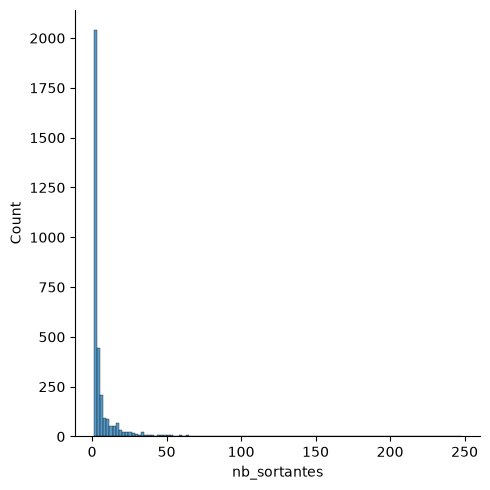

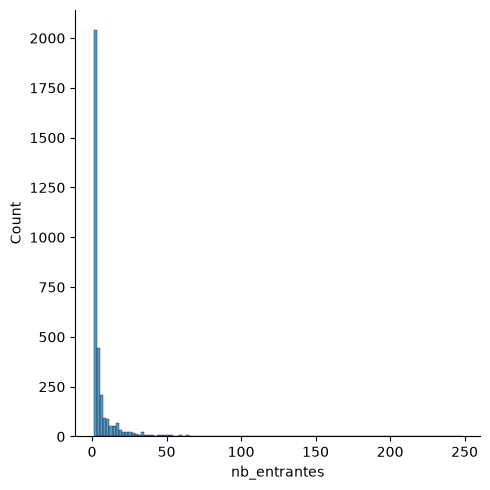

In [13]:
# graph sur les connexions
sns.displot(nb_connection_sortantes,
            x="nb_sortantes")

sns.displot(nb_connection_entrantes,
            x="nb_entrantes")

df_fusionne = pd.merge(nb_connection_sortantes, nb_connection_entrantes, on='airport', how='outer')

# les graphiques montrent une grande hétérogénéité dans le nombre de connexions sortantes et entrantes des aéroports
# la majorité ont peu de connexions( moins de 20) et quelques aéroports en ont beaucoup ( jusqu'à 250)


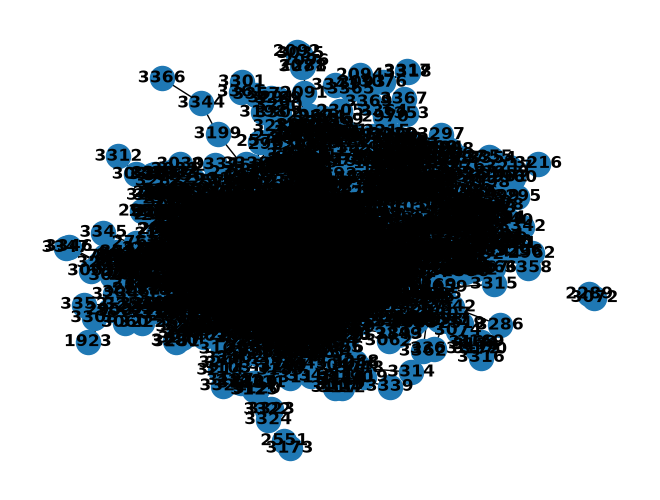

In [14]:
# le graph est très resseré avec quelques noeuds éloignés
nx.draw(graph, with_labels=True, font_weight='bold')

In [15]:
data_0.edge_index
indices_pays = th.tensor(LabelEncoder().fit_transform(data_0.country))
print()
for titre, paires in [("vraies routes", data_0.edge_index)]:
    meme_pays = (indices_pays[paires[0]] == indices_pays[paires[1]]).float().mean()
    print(f"Test, {titre} : {meme_pays:.1%} relient deux aéroports du même pays")


Test, vraies routes : 57.4% relient deux aéroports du même pays


In [16]:
# on construit des nouvelles features pour l'apprentissage du modèle GNN
# la population est transformée par log(1 + population) puis standardisée
# la longitude et la latitude sont transformées en coordonnées 3D sur la sphère
# les pays sont encodés en one-hot

import copy
x_brut = data_0.x.float()

# Normalisation : log(1 + population), puis standardisation de chaque colonne
x_log = x_brut.clone()
x_log[:, 2] = th.log1p(x_log[:, 2])
x_normalise = (x_log - x_log.mean(dim=0)) / x_log.std(dim=0)
log_pop = x_normalise[:, 2:3]

# Coordonnées 3D sur la sphère
lon_rad = th.deg2rad(x_brut[:, 0])
lat_rad = th.deg2rad(x_brut[:, 1])
coord_3d = th.stack([
    th.cos(lat_rad) * th.cos(lon_rad),  # x
    th.cos(lat_rad) * th.sin(lon_rad),  # y
    th.sin(lat_rad),                    # z
], dim=1)

# One-hot du pays : chaque pays reçoit un indice (LabelEncoder), puis on crée le vecteur one-hot
indices_pays = th.tensor(LabelEncoder().fit_transform(data_0.country))
pays_one_hot = F.one_hot(indices_pays).float()

features = {
    "normalisées": x_normalise,
    "3D": th.cat([coord_3d, log_pop], dim=1),
    "3D + pays": th.cat([coord_3d, log_pop, pays_one_hot], dim=1),
}

def avec_features(donnees, x):
    # même graphe et mêmes paires à prédire, seules les features des nœuds changent
    donnees_bis = copy.copy(donnees)
    donnees_bis.x = x
    return donnees_bis

colonnes = ["longitude", "latitude", "population"]
print("Features brutes :\n", pd.DataFrame(x_brut.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))
print("\nFeatures normalisées :\n", pd.DataFrame(x_normalise.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))

print()
for nom, x in features.items():
    print(f"{nom} : {x.size(1)} features par aéroport")

# Exemple : -179° et +179° de longitude sont loin en (lon, lat) mais proches en 3D
print()
for lon in [-179.0, 179.0]:
    l = th.deg2rad(th.tensor(lon))
    print(f"lon = {lon:+.0f}°, lat = 0° -> (x, y, z) = ({th.cos(l):.3f}, {th.sin(l):.3f}, 0.000)")

# Pourquoi le pays est utile : part des paires dans le même pays, vraies routes vs paires négatives
print()
for titre, paires in [("vraies routes", data_0.edge_index)]:
    meme_pays = (indices_pays[paires[0]] == indices_pays[paires[1]]).float().mean()
    print(f"Test, {titre} : {meme_pays:.1%} relient deux aéroports du même pays")

Features brutes :
       longitude  latitude   population
mean       0.70     23.02    338077.66
std       96.47     29.33   1262323.12
min     -179.87    -54.82       637.00
max      179.90     78.25  22315474.00

Features normalisées :
       longitude  latitude  population
mean       0.00      0.00        0.00
std        1.00      1.00        1.00
min       -1.87     -2.65       -2.31
max        1.86      1.88        3.46

normalisées : 3 features par aéroport
3D : 4 features par aéroport
3D + pays : 216 features par aéroport

lon = -179°, lat = 0° -> (x, y, z) = (-1.000, -0.017, 0.000)
lon = +179°, lat = 0° -> (x, y, z) = (-1.000, 0.017, 0.000)

Test, vraies routes : 57.4% relient deux aéroports du même pays


In [17]:
# les longitudes et latitudes sont normalisées en coordonnées 3D
# les pays one hot encodés
# on note que la variable pays est particulièrement interressantes pour prédire les liens

# on normalise les données en ajoutant les features 3D + pays_one_hot
data_1 = avec_features(data_0, features["normalisées"])
data_2 = avec_features(data_0, features["3D"])
data_3 = avec_features(data_0, features["3D + pays"])


print(data_1)
print(data_2)
print(data_3)


Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 3])
Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 4])
Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 216])


In [18]:
#  on divise le set en train , val et test et on sauvegarde les fichiers
from turtle import save

from torch import save
from torch_geometric.transforms import RandomLinkSplit

#transform = RandomLinkSplit(is_undirected=True)

transform = RandomLinkSplit(is_undirected=True,split_labels=True)
# un seul split (fixé par la seed) : tous les jeux ont exactement les mêmes arêtes en train / val / test,
# seules les features des nœuds changent -> les comparaisons entre jeux de données sont équitables
th.manual_seed(0)
train_data_0, val_data_0, test_data_0 = transform(data_0)
train_data_1, val_data_1, test_data_1 = (avec_features(d, features["normalisées"]) for d in (train_data_0, val_data_0, test_data_0))
train_data_2, val_data_2, test_data_2 = (avec_features(d, features["3D"]) for d in (train_data_0, val_data_0, test_data_0))
train_data_3, val_data_3, test_data_3 = (avec_features(d, features["3D + pays"]) for d in (train_data_0, val_data_0, test_data_0))


save(data_0, '../data/data_0.pt')
save(data_1, '../data/data_1.pt')
save(data_2, '../data/data_2.pt')
save(data_3, '../data/data_3.pt')
save(train_data_0,'../data/train_data_0.pt')
save(val_data_0, '../data/val_data_0.pt')
save(test_data_0, '../data/test_data_0.pt')
save(train_data_1, '../data/train_data_1.pt')
save(val_data_1, '../data/val_data_1.pt')
save(test_data_1, '../data/test_data_1.pt')
save(train_data_2, '../data/train_data_2.pt')
save(val_data_2, '../data/val_data_2.pt')
save(test_data_2, '../data/test_data_2.pt')
save(train_data_3, '../data/train_data_3.pt')
save(val_data_3, '../data/val_data_3.pt')
save(test_data_3, '../data/test_data_3.pt')
print("sauvegarde terminée")

sauvegarde terminée
